In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


Now, I want to try to use SMOTE on training data to deal with class imbalance 

In [2]:
df = pd.read_parquet("../../data/model_ready/flights_model_ready.parquet")
df.head()


,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,near_holiday_3d
0,2018-01-03,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,3,Wednesday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Delayed,2018-01-03,10,27.0,10.0,6.000000,0.0,40.42,0.0,2,0.5,0.866025,0.974928,-0.222521,-1.181369,-1.795908,0.372,-0.268741,-1.032586,-0.532803,-506.21629,0,0,1
1,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,Thursday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.1,10.0,14.166667,0.0,54.36,21.0,3,0.5,0.866025,0.433884,-0.900969,-1.181369,-1.949265,0.372,1.558113,-0.405039,1.744748,-506.21629,0,0,1
2,2018-01-05,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,5,Friday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8877A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-05,10,17.1,10.0,12.153846,0.0,55.51,0.0,4,0.5,0.866025,-0.433884,-0.900969,-1.181369,-2.319438,0.372,1.107853,-0.353268,-0.532803,-506.21629,0,0,0
3,2018-01-06,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,6,Saturday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8970D,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-06,10,21.9,10.0,6.846154,0.0,57.02,0.0,5,0.5,0.866025,-0.974928,-0.222521,-1.181369,-2.065605,0.372,-0.079459,-0.285291,-0.532803,-506.21629,0,0,0
4,2018-01-07,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,7,Sunday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8980A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-07,10,21.9,10.0,7.384615,0.0,54.75,0.0,6,0.5,0.866025,-0.781831,0.623490,-1.181369,-2.065605,0.372,0.040993,-0.387482,-0.532803,-506.21629,0,0,0


In [3]:
df.shape

(14539250, 67)

In [4]:
df.isnull().sum().sort_values(ascending=False).head(20)

Tail_Number       51887
relh_std          15364
relh              15364
CRSElapsedTime        7
FlightDate            0
date                  0
sknt                  0
vsby                  0
tmpf                  0
dep_hour              0
year                  0
target                0
DistanceGroup         0
ArrTimeBlk            0
CRSArrTime            0
DepTimeBlk            0
DestWac               0
p01i                  0
gust                  0
DestStateFips         0
dtype: int64

In [5]:
# lets add some new features 
df.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,near_holiday_3d
0,2018-01-03,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,3,Wednesday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Delayed,2018-01-03,10,27.0,10.0,6.000000,0.0,40.42,0.0,2,0.5,0.866025,0.974928,-0.222521,-1.181369,-1.795908,0.372,-0.268741,-1.032586,-0.532803,-506.21629,0,0,1
1,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,Thursday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.1,10.0,14.166667,0.0,54.36,21.0,3,0.5,0.866025,0.433884,-0.900969,-1.181369,-1.949265,0.372,1.558113,-0.405039,1.744748,-506.21629,0,0,1
2,2018-01-05,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,5,Friday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8877A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-05,10,17.1,10.0,12.153846,0.0,55.51,0.0,4,0.5,0.866025,-0.433884,-0.900969,-1.181369,-2.319438,0.372,1.107853,-0.353268,-0.532803,-506.21629,0,0,0
3,2018-01-06,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,6,Saturday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8970D,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-06,10,21.9,10.0,6.846154,0.0,57.02,0.0,5,0.5,0.866025,-0.974928,-0.222521,-1.181369,-2.065605,0.372,-0.079459,-0.285291,-0.532803,-506.21629,0,0,0
4,2018-01-07,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,7,Sunday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8980A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-07,10,21.9,10.0,7.384615,0.0,54.75,0.0,6,0.5,0.866025,-0.781831,0.623490,-1.181369,-2.065605,0.372,0.040993,-0.387482,-0.532803,-506.21629,0,0,0


In [6]:
import sys
from pathlib import Path

# Get the root project directory (two levels up from the notebook)
project_root = Path.cwd().parents[1]  # notebooks/ → project root
scripts_path = project_root / "scripts"
sys.path.append(str(scripts_path))

# Now you can import your function
from sampling_split import sample_and_split


In [7]:
# train_df, val_df, test_df = sample_and_split(
#     df,
#     total_sample=500_000,
#     max_origin_frac=0.05,
#     max_region_frac=0.3,
#     test_size=0.2,
#     val_frac_of_train=0.25,
#     output_dir="../../data/model_ready/sampled_splits",
#     random_state=42
# )

In [8]:
train_df = pd.read_parquet("../../data/model_ready/sampled_splits/train.parquet")
val_df = pd.read_parquet("../../data/model_ready/sampled_splits/val.parquet")
test_df = pd.read_parquet("../../data/model_ready/sampled_splits/test.parquet")
print(f"train shape: {train_df.shape}")
print(f"val shape: {val_df.shape}")
print(f"test shape: {test_df.shape}")


train shape: (134639, 69)
val shape: (44880, 69)
test shape: (44880, 69)


In [9]:
train_df.target.value_counts(normalize=True)

target
On time      0.611792
Delayed      0.352840
Cancelled    0.035369
Name: proportion, dtype: float64

In [10]:
#pip install imbalanced-learn
#pip install -U scikit-learn imbalanced-learn



In [11]:
from imblearn.over_sampling import SMOTE

In [13]:
train_df.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,near_holiday_3d,month,OriginRegion
0,2018-07-11,"Commutair Aka Champlain Enterprises, Inc.",EWR,CLE,1509,106.0,404.0,2018,3,7,11,Wednesday,UA,UA_CODESHARE,19977,UA,4883,C5,20445,C5,N12175,4883,11618,1161802,31703,"Newark, NJ",NJ,34,New Jersey,21,11042,1104205,30647,"Cleveland, OH",OH,39,Ohio,44,1500-1559,1655,1600-1659,2,2018,On time,2018-07-11,15,85.0,10.0,11.615385,0.0,46.42,19.0,2,-5.000000e-01,-8.660254e-01,0.974928,-0.222521,-0.754961,1.271237,0.372,0.987401,-0.762479,1.527839,-596.348289,0,0,0,2018-07,Northeast
1,2019-12-24,Southwest Airlines Co.,DEN,BWI,1340,200.0,1491.0,2019,4,12,24,Tuesday,WN,WN,19393,WN,6303,WN,19393,WN,N8510E,6303,11292,1129202,30325,"Denver, CO",CO,8,Colorado,82,10821,1082106,30852,"Baltimore, MD",MD,24,Maryland,35,1300-1359,1900,1900-1959,6,2019,On time,2019-12-24,13,37.0,10.0,6.615385,0.0,36.63,0.0,1,-2.449294e-16,1.000000e+00,0.781831,0.623490,1.034634,-1.267090,0.372,-0.131081,-1.203203,-0.532803,635.595217,0,0,1,2019-12,West
2,2019-05-26,American Airlines Inc.,DFW,PIT,1103,167.0,1067.0,2019,2,5,26,Sunday,AA,AA,19805,AA,1551,AA,19805,AA,N861NN,1551,11298,1129806,30194,"Dallas/Fort Worth, TX",TX,48,Texas,74,14122,1412202,30198,"Pittsburgh, PA",PA,42,Pennsylvania,23,1100-1159,1450,1400-1459,5,2019,On time,2019-05-26,11,73.0,10.0,10.615385,0.0,84.34,0.0,6,5.000000e-01,-8.660254e-01,-0.781831,0.623490,0.336576,0.636656,0.372,0.763704,0.944593,-0.532803,279.676222,0,0,1,2019-05,South
3,2018-01-02,Alaska Airlines Inc.,SEA,LAS,1928,152.0,867.0,2018,1,1,2,Tuesday,AS,AS,19930,AS,616,AS,19930,AS,N553AS,616,14747,1474703,30559,"Seattle, WA",WA,53,Washington,93,12889,1288903,32211,"Las Vegas, NV",NV,32,Nevada,85,1900-1959,2200,2200-2259,4,2018,Delayed,2018-01-02,19,41.0,10.0,4.615385,0.0,67.03,0.0,1,5.000000e-01,8.660254e-01,0.781831,0.623490,0.007304,-1.055562,0.372,-0.578474,0.165336,-0.532803,-216.845398,0,0,1,2018-01,West
4,2019-09-04,United Air Lines Inc.,PHL,IAH,1740,218.0,1325.0,2019,3,9,4,Wednesday,UA,UA,19977,UA,1765,UA,19977,UA,N37409,1765,14100,1410005,34100,"Philadelphia, PA",PA,42,Pennsylvania,23,12266,1226603,31453,"Houston, TX",TX,48,Texas,74,1700-1759,2018,2000-2059,6,2019,On time,2019-09-04,17,91.0,10.0,16.846154,0.0,45.24,0.0,2,-1.000000e+00,-1.836970e-16,0.974928,-0.222521,0.761338,1.588528,0.372,2.157505,-0.815600,-0.532803,575.796712,0,0,1,2019-09,Northeast


In [15]:
# Smote only takes numerical values

In [ ]:

smote = SMOTE(random_state=42)

## Random Forest Model Smote (only numerical)

In [21]:
FEATURES = ["Quarter", "Month", "DayofMonth", "dep_hour", 
 "Distance",
    "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
     #"DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
]

TARGET = "target"


In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numerical
# categorical_features = [
#     "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
# ]

numeric_features = [
    "Quarter", "Month", "DayofMonth", "dep_hour",
    "Distance", "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
       # ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)



In [23]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


In [24]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])


In [27]:
# Convert categorical columns to string (needed for OneHotEncoder)
# for col in categorical_features:
#     train_df[col] = train_df[col].astype(str)
#     val_df[col]   = val_df[col].astype(str)
#     test_df[col]  = test_df[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    train_df[col] = train_df[col].fillna(0)
    val_df[col]   = val_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
# for col in categorical_features:
#     train_df[col] = train_df[col].fillna("missing")
#     val_df[col]   = val_df[col].fillna("missing")
#     test_df[col]  = test_df[col].fillna("missing")

In [28]:
X_train_smote, y_train_smote = smote.fit_resample(train_df[FEATURES], train_df.target)


In [35]:
pipeline.fit(X_train_smote[FEATURES], y_train_smote)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Quarter', 'Month',
                                                   'DayofMonth', 'dep_hour',
                                                   'Distance', 'tmpf', 'vsby',
                                                   'sknt', 'p01i', 'relh',
                                                   'gust'])])),
                ('rf',
                 RandomForestClassifier(max_depth=15, n_estimators=80,
                                        n_jobs=-1, random_state=42))])

The test set stays the same when using SMOTE.

In [36]:
# Predictions
y_pred = pipeline.predict(test_df[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(test_df[TARGET], y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(test_df[TARGET], y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)



Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.112     0.339     0.168      1587
     Delayed      0.473     0.449     0.461     15836
     On time      0.704     0.642     0.672     27457

    accuracy                          0.563     44880
   macro avg      0.430     0.477     0.434     44880
weighted avg      0.602     0.563     0.579     44880


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.339004  0.321361  0.339635
Delayed     0.117264  0.448788  0.433948
On time     0.087883  0.269913  0.642204


Test Accuracy: 0.563

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        538      510      539
Delayed         1857     7107     6872
On time         2413     7411    17633

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.339004  0.321361  0.339635
Delayed     0.117264  0.448788  0.433948
On time     0.087883  0.269913  0.642204


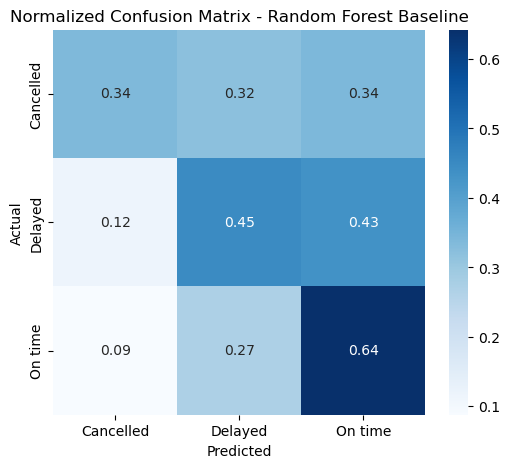


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.112     0.339     0.168      1587
     Delayed      0.473     0.449     0.461     15836
     On time      0.704     0.642     0.672     27457

    accuracy                          0.563     44880
   macro avg      0.430     0.477     0.434     44880
weighted avg      0.602     0.563     0.579     44880



In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(test_df[FEATURES])
y_true = test_df[TARGET]

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))


Applying SMOTE to balance the dataset resulted in improved detection of minority classes. Recall for cancellations increased to 34%, and nearly 45% of delays were correctly identified. The improvement comes at the expense of precision and on-time flight recall, which dropped to 64%. 

This illustrates the expected tradeoff when oversampling rare events: the classifier becomes more sensitive to disruptions but also more prone to false alarms. Overall, the model demonstrates that synthetic oversampling can help address class imbalance and better align predictions with operational priorities.


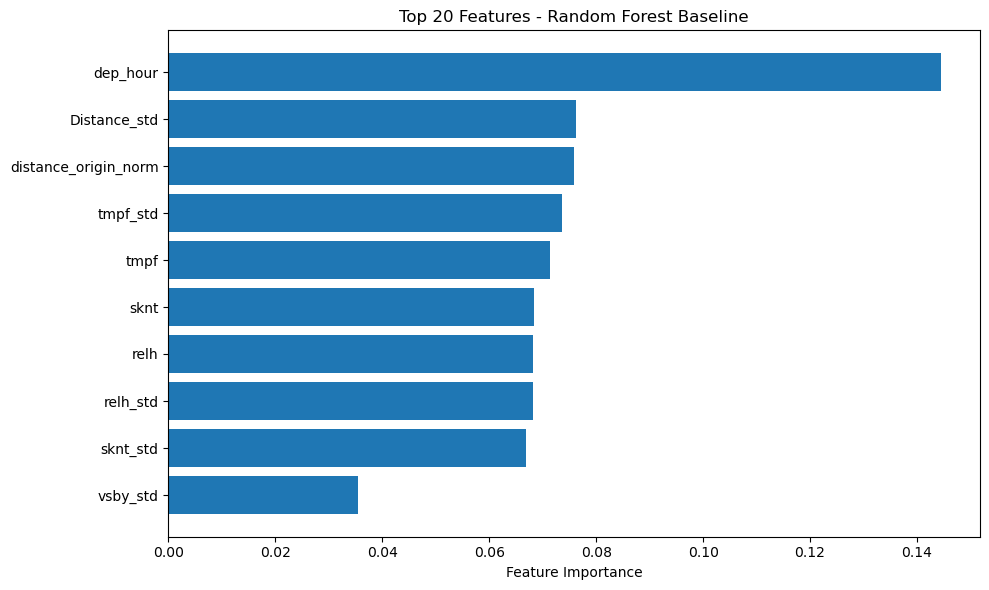

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
#cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
#all_features = np.concatenate([cat_features, numeric_features])
all_features = np.array(numeric_features)


# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]

sorted_features = all_features[indices]

sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()


In [41]:
importances

array([0.07522113, 0.08343494, 0.06940501, 0.08730016, 0.11431755,
       0.13573127, 0.10225785, 0.08882162, 0.08322439, 0.09699915,
       0.06328691])

### Now lets try with the class_Weight = "balanced"

In [46]:
FEATURES = ["Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour", "DepTimeBlk",
    "Airline", "Origin", "Dest", "Distance", "DistanceGroup",
    "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

TARGET = "target"


In [47]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numerical
categorical_features = [
    "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
]

numeric_features = [
    "Quarter", "Month", "DayofMonth", "dep_hour",
    "Distance", "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [48]:
rf_model = RandomForestClassifier(class_weight="balanced",
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


In [49]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])

In [50]:
# Convert categorical columns to string (needed for OneHotEncoder)
for col in categorical_features:
    train_df[col] = train_df[col].astype(str)
    val_df[col]   = val_df[col].astype(str)
    test_df[col]  = test_df[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    train_df[col] = train_df[col].fillna(0)
    val_df[col]   = val_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
for col in categorical_features:
    train_df[col] = train_df[col].fillna("missing")
    val_df[col]   = val_df[col].fillna("missing")
    test_df[col]  = test_df[col].fillna("missing")


In [51]:
pipeline.fit(train_df[FEATURES], train_df[TARGET])


/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['DepTimeBlk', 'Airline',
                                                   'Origin', 'Dest',
                                                   'DistanceGroup',
                                                   'DayOfWeek']),
                                                 ('num', 'passthrough',
                                                  ['Quarter', 'Month',
                                                   'DayofMonth', 'dep_hour',
                                                   'Distance', 'tmpf', 'vsby',
                                                   'sknt', 'p01i', 'relh',
                                                   'gust'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

In [52]:
# Predictions
y_pred = pipeline.predict(test_df[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(test_df[TARGET], y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(test_df[TARGET], y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)

Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.134     0.361     0.196      1587
     Delayed      0.477     0.534     0.504     15836
     On time      0.727     0.606     0.661     27457

    accuracy                          0.572     44880
   macro avg      0.446     0.500     0.454     44880
weighted avg      0.618     0.572     0.589     44880


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.361059  0.330183  0.308759
Delayed     0.103183  0.533784  0.363034
On time     0.074881  0.318680  0.606439


Using cost-sensitive learning with balanced class weights significantly changed model behavior. Although overall accuracy decreased to 57%, recall for cancellations increased dramatically to 36%, and delay detection exceeded 50%. This indicates the classifier is no longer dominated by the majority class and is actively attempting to identify operational disruptions. The improvement comes at the expense of precision, as more flights are incorrectly flagged, illustrating the inherent tradeoff between sensitivity and false alarms.

For airlines, it it better to predict delayed or canclled and get it wrong than to predict an on-time flight and it is wrong. 

1. Operational Impact

If an airline predicts a flight is delayed or cancelled and it’s actually on time (false alarm), the cost is usually small: maybe a minor crew or gate adjustment, or some customer notifications.

If the airline predicts a flight is on time and it is actually delayed or cancelled (missed disruption), the cost is much higher:

Passengers miss connections

Crew schedules are disrupted

Gates may need rescheduling

Rebooking costs increase

2. Passenger Experience

False alarms are annoying but manageable.

Missed disruptions cause cascading failures and customer dissatisfaction.

3. Industry Practice

Airlines often prefer sensitive systems:

“Better to give a warning that may be unnecessary than no warning at all.”

This is exactly why class weighting, SMOTE, and recall-focused models are used — they prioritize detecting rare events (delays/cancellations) over maximizing overall accuracy.

Test Accuracy: 0.572

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        573      524      490
Delayed         1634     8453     5749
On time         2056     8750    16651

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.361059  0.330183  0.308759
Delayed     0.103183  0.533784  0.363034
On time     0.074881  0.318680  0.606439


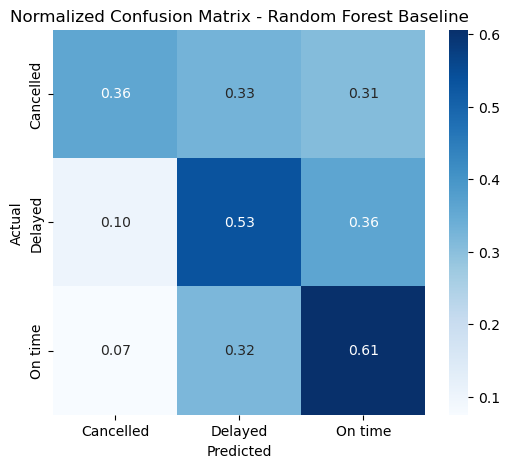


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.134     0.361     0.196      1587
     Delayed      0.477     0.534     0.504     15836
     On time      0.727     0.606     0.661     27457

    accuracy                          0.572     44880
   macro avg      0.446     0.500     0.454     44880
weighted avg      0.618     0.572     0.589     44880



In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(test_df[FEATURES])
y_true = test_df[TARGET]

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))

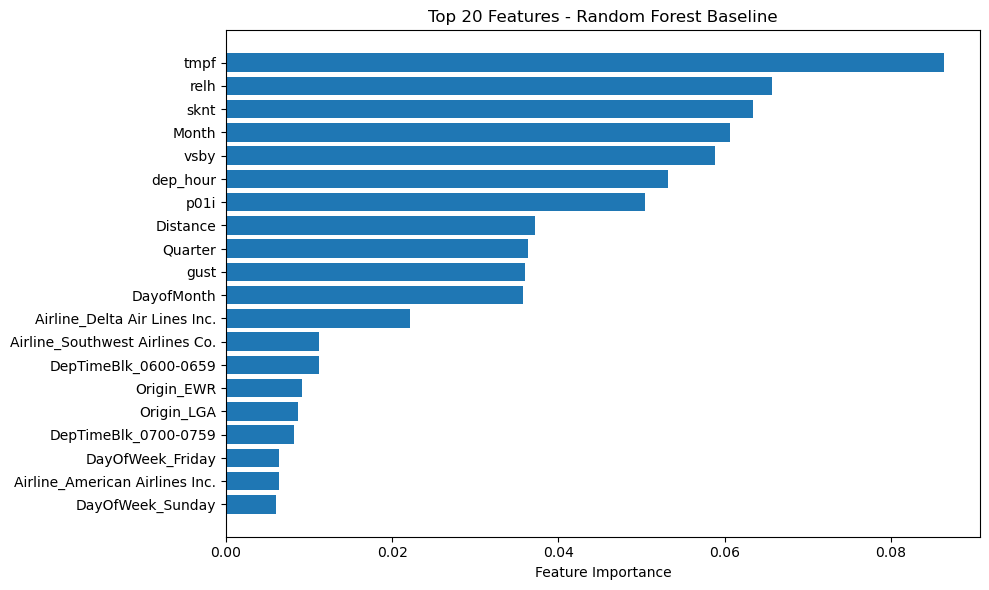

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = np.concatenate([cat_features, numeric_features])

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()


### Now, lets do some of the new features we used that are only numerical

In [55]:
df.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,near_holiday_3d
0,2018-01-03,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,3,Wednesday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Delayed,2018-01-03,10,27.0,10.0,6.000000,0.0,40.42,0.0,2,0.5,0.866025,0.974928,-0.222521,-1.181369,-1.795908,0.372,-0.268741,-1.032586,-0.532803,-506.21629,0,0,1
1,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,Thursday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.1,10.0,14.166667,0.0,54.36,21.0,3,0.5,0.866025,0.433884,-0.900969,-1.181369,-1.949265,0.372,1.558113,-0.405039,1.744748,-506.21629,0,0,1
2,2018-01-05,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,5,Friday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8877A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-05,10,17.1,10.0,12.153846,0.0,55.51,0.0,4,0.5,0.866025,-0.433884,-0.900969,-1.181369,-2.319438,0.372,1.107853,-0.353268,-0.532803,-506.21629,0,0,0
3,2018-01-06,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,6,Saturday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8970D,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-06,10,21.9,10.0,6.846154,0.0,57.02,0.0,5,0.5,0.866025,-0.974928,-0.222521,-1.181369,-2.065605,0.372,-0.079459,-0.285291,-0.532803,-506.21629,0,0,0
4,2018-01-07,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,7,Sunday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8980A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-07,10,21.9,10.0,7.384615,0.0,54.75,0.0,6,0.5,0.866025,-0.781831,0.623490,-1.181369,-2.065605,0.372,0.040993,-0.387482,-0.532803,-506.21629,0,0,0


In [56]:
# FEATURES = ["Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour", "DepTimeBlk",
#     "Airline", "Origin", "Dest", "Distance", "DistanceGroup",
#     "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
FEATURES = ["dep_hour",	"tmpf",	"vsby",	"sknt",
        "p01i",	"relh",	"gust",	"DayOfWeek_num", "month_sin",	"month_cos",
        "dow_sin",	"dow_cos",	"Distance_std",	"tmpf_std",
        "vsby_std",	"sknt_std",	"relh_std",	"gust_std",	"distance_origin_norm",
        "has_precip",	"is_holiday",	"near_holiday_3d"
]

TARGET = "target"

In [57]:
# Split categorical vs numerical
# categorical_features = [
#     "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
# ]

numeric_features = [
"dep_hour",	"tmpf",	"vsby",	"sknt",
        "p01i",	"relh",	"gust",	"DayOfWeek_num", "month_sin",	"month_cos",
        "dow_sin",	"dow_cos",	"Distance_std",	"tmpf_std",
        "vsby_std",	"sknt_std",	"relh_std",	"gust_std",	"distance_origin_norm",
        "has_precip",	"is_holiday",	"near_holiday_3d"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        #("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [58]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)

In [59]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])

In [60]:
for col in categorical_features:
    train_df[col] = train_df[col].astype(str)
    val_df[col]   = val_df[col].astype(str)
    test_df[col]  = test_df[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    train_df[col] = train_df[col].fillna(0)
    val_df[col]   = val_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
for col in categorical_features:
    train_df[col] = train_df[col].fillna("missing")
    val_df[col]   = val_df[col].fillna("missing")
    test_df[col]  = test_df[col].fillna("missing")

In [61]:
pipeline.fit(train_df[FEATURES], train_df[TARGET])

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['dep_hour', 'tmpf', 'vsby',
                                                   'sknt', 'p01i', 'relh',
                                                   'gust', 'DayOfWeek_num',
                                                   'month_sin', 'month_cos',
                                                   'dow_sin', 'dow_cos',
                                                   'Distance_std', 'tmpf_std',
                                                   'vsby_std', 'sknt_std',
                                                   'relh_std', 'gust_std',
                                                   'distance_origin_norm',
                                                   'has_precip', 'is_holiday',
                                                   'near_holiday_3d'])])),
                ('rf',
                 RandomForestClassifier(max_depth=15, n_estimators=80,
                                        n_jobs=-1, random_state=42))])

In [62]:
# Predictions
y_pred = pipeline.predict(test_df[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(test_df[TARGET], y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(test_df[TARGET], y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)

Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.682     0.064     0.116      1587
     Delayed      0.569     0.242     0.340     15836
     On time      0.657     0.909     0.763     27457

    accuracy                          0.644     44880
   macro avg      0.636     0.405     0.406     44880
weighted avg      0.627     0.644     0.591     44880


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.063642  0.269061  0.667297
Delayed     0.002147  0.242422  0.755431
On time     0.000473  0.090214  0.909313


Test Accuracy: 0.644

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        101      427     1059
Delayed           34     3839    11963
On time           13     2477    24967

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.063642  0.269061  0.667297
Delayed     0.002147  0.242422  0.755431
On time     0.000473  0.090214  0.909313


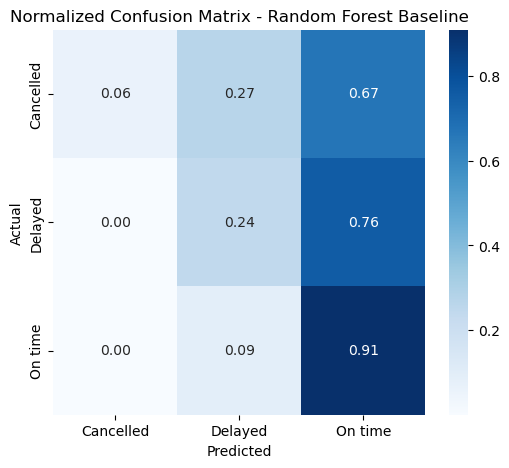


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.682     0.064     0.116      1587
     Delayed      0.569     0.242     0.340     15836
     On time      0.657     0.909     0.763     27457

    accuracy                          0.644     44880
   macro avg      0.636     0.405     0.406     44880
weighted avg      0.627     0.644     0.591     44880



In [63]:
# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(test_df[FEATURES])
y_true = test_df[TARGET]

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))

The updated Random Forest model achieved an accuracy of 64.4%. While the overall accuracy increased only slightly, the model showed substantial improvement in detecting minority classes. Recall for delayed flights increased to 24%, allowing the system to identify nearly one in four disruptions. Cancellation detection also improved, though recall remains low at 6%. This demonstrates the classic tradeoff in imbalanced classification: as the model becomes more sensitive to rare events, performance on the majority class decreases slightly. Despite the progress, most delays and cancellations are still misclassified as on-time, indicating further work is needed.

Changes from baseline model

| Class     | Before | After |
| --------- | ------ | ----- |
| Cancelled | ~0%    | 6%    |
| Delayed   | 11%    | 24%   |


['dep_hour' 'tmpf' 'vsby' 'sknt' 'p01i' 'relh' 'gust' 'DayOfWeek_num'
 'month_sin' 'month_cos' 'dow_sin' 'dow_cos' 'Distance_std' 'tmpf_std'
 'vsby_std' 'sknt_std' 'relh_std' 'gust_std' 'distance_origin_norm'
 'has_precip' 'is_holiday' 'near_holiday_3d']


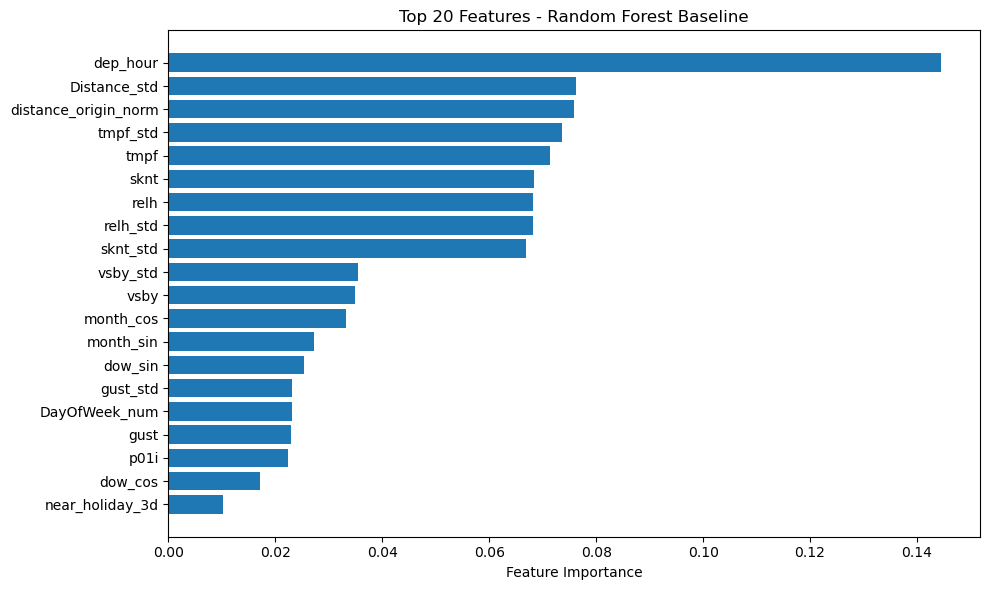

In [72]:
# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
#cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
#all_features = np.concatenate([cat_features, numeric_features])
all_features =  np.array(numeric_features)
print(all_features)

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()